<h2> Neural Architecture Search (NAS) with Q-Learning </h2>

<h4> This notebook demonstrates how Q-Learning, a reinforcement learning technique, can be used for Neural Architecture Search (NAS) to improve the performance of a FashionMNIST CNN model. </h4>

<h3> Import Libraries </h3>

In [ ]:
# install requirements
!pip install -r requirements.txt

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import visualkeras
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings('ignore')

<h3>Load and preprocess the Fashion MNIST dataset </h3>

In [13]:
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_val = x_val.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)


<h3>  Step 1: Train a basic CNN model </h3>

In [20]:
print("### Step 1: Training a Basic CNN Model")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

### Step 1: Training a Basic CNN Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

<h4> Visualize the CNN architecture </h4>

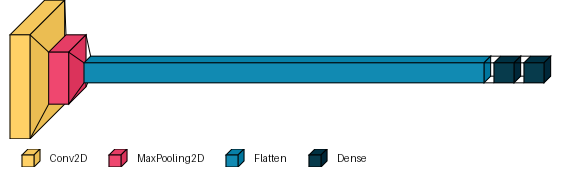

In [27]:
visualkeras.layered_view(model, legend=True)

<h4>  Evaluate baseline performance </h4>

In [30]:
test_loss, test_accuracy = model.evaluate(x_val, y_val, verbose=2)
print(f"Baseline Test Accuracy: {test_accuracy:.2f}")

313/313 - 2s - 7ms/step - accuracy: 0.0673 - loss: 2.3232
Baseline Test Accuracy: 0.07


<h3>  Step 2: Define Action Space and Q-learning Table </h3>

In [47]:
def visualize_q_table(q_table):
    plt.figure(figsize=(5, 3))
    sns.heatmap(q_table, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Q-Table Visualization")
    plt.xlabel("Actions (Kernel Size)")
    plt.ylabel("States (Filters)")
    plt.show()

In [41]:

states = ['s1', 's2', 's3']  # Different filter configurations
actions = ['3x3', '5x5', '7x7']  # Different kernel sizes
q_table = np.random.rand(len(states), len(actions))

Initial Q-Table:


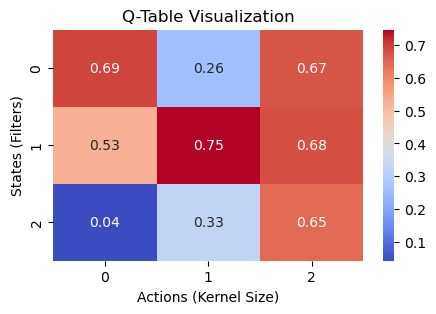

In [49]:
print("Initial Q-Table:")
visualize_q_table(q_table)

<h3> Step 3: Implement Epsilon-Greedy Policy </h3>

In [54]:
epsilon = 0.1  # Exploration rate
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor


In [56]:
def get_action(state_idx):
    if np.random.rand() < epsilon:
        return np.random.choice(len(actions))
    else:
        return np.argmax(q_table[state_idx])

<h3> Step 4: Train the CNN based on Selected Architecture </h3>

In [59]:
def train_cnn(filters, kernel_size):
    model = models.Sequential([
        layers.Conv2D(filters, (kernel_size, kernel_size), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=3, batch_size=64, verbose=0)
    return max(history.history['val_accuracy'])


<h3> Step 5: Run Q-Learning Algorithm </h3>

In [66]:
val_accuracies = []  # Store validation accuracy per episode

for episode in range(num_episodes):
    print(f"Episode {episode + 1}:")
    state_idx = np.random.choice(len(states))
    state = states[state_idx]
    action_idx = get_action(state_idx)
    action = actions[action_idx]
    
    num_filters = 32 if state == 's1' else 64 if state == 's2' else 128
    kernel_size = int(action[0])  # Extract kernel size from string
    
    val_accuracy = train_cnn(num_filters, kernel_size)
    val_accuracies.append(val_accuracy)  # Store accuracy

    reward = val_accuracy
    max_future_q = np.max(q_table[action_idx])
    current_q = q_table[state_idx, action_idx]
    new_q = (1 - alpha) * current_q + alpha * (reward + gamma * max_future_q)
    q_table[state_idx, action_idx] = new_q
    
    print(f"State: {state}, Action: {action}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Updated Q-Value: {new_q:.4f}\n")



Episode 1:
State: s3, Action: 7x7, Validation Accuracy: 0.8877
Updated Q-Value: 0.8110

Episode 2:
State: s1, Action: 3x3, Validation Accuracy: 0.9028
Updated Q-Value: 1.0987

Episode 3:
State: s1, Action: 3x3, Validation Accuracy: 0.9028
Updated Q-Value: 1.1780

Episode 4:
State: s3, Action: 7x7, Validation Accuracy: 0.8993
Updated Q-Value: 0.8928

Episode 5:
State: s1, Action: 3x3, Validation Accuracy: 0.8941
Updated Q-Value: 1.2557

Episode 6:
State: s2, Action: 5x5, Validation Accuracy: 0.8974
Updated Q-Value: 0.9918

Episode 7:
State: s3, Action: 7x7, Validation Accuracy: 0.9006
Updated Q-Value: 0.9740

Episode 8:
State: s2, Action: 5x5, Validation Accuracy: 0.9015
Updated Q-Value: 1.0720

Episode 9:
State: s3, Action: 3x3, Validation Accuracy: 0.9067
Updated Q-Value: 0.2425

Episode 10:
State: s3, Action: 7x7, Validation Accuracy: 0.9000
Updated Q-Value: 1.0542



Final Q-Table after Training:


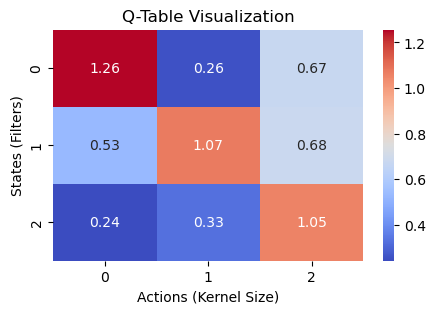

In [74]:
print("Final Q-Table after Training:")
visualize_q_table(q_table)


<h4> Plot Validation Accuracy Over Episodes </h4>

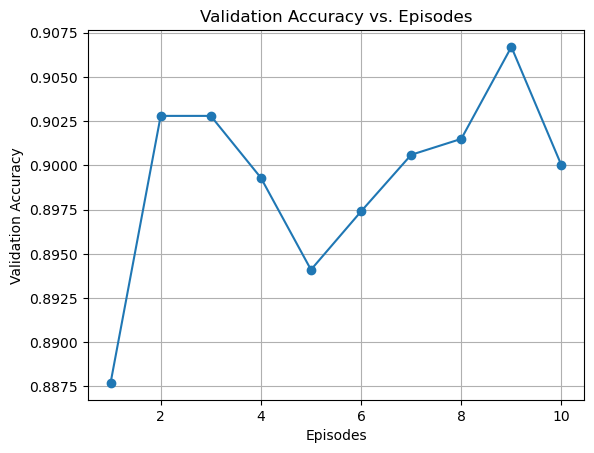

In [68]:

plt.plot(range(1, num_episodes + 1), val_accuracies, marker='o', linestyle='-')
plt.xlabel("Episodes")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. Episodes")
plt.grid()
plt.show()


<h4>Since the highest validation accuracy was achieved during the 9th iteration, we can select the corresponding configuration (State: s3, Action: 3x3) as the optimal architecture for our model. </h4>